#Import Packages & Load the Dataset

The following is the code used to export and filter the large dataset we pulled from Kaggle - it was too large to export to Excel so I needed to filter it from the zip file.

import pandas as pd
import zipfile

chunks = []

with zipfile.ZipFile("/content/archive (3).zip") as z:
    file_name = z.namelist()[0]

    with z.open(file_name) as f:
        for chunk in pd.read_csv(
            f,
            chunksize=100000,
            engine="python",
            on_bad_lines="skip"
        ):
            nc_chunk = chunk[chunk['origin_state_nm'] == 'North Carolina']
            chunks.append(nc_chunk)

df_nc = pd.concat(chunks)

df_nc.to_csv("nc_flights_2024.csv", index=False)

print("Done!")
print(df_nc.shape)
print(df_nc['month'].value_counts().sort_index())

In [ ]:
!pip install mlba
!pip install lime

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier


from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import BaggingClassifier

from mlba import classificationSummary, plotDecisionTree
from lime.lime_tabular import LimeTabularExplainer

from sklearn.metrics import (
    roc_curve,
    auc,
    precision_recall_curve,
    average_precision_score,
    roc_auc_score,
    accuracy_score)
from mlba import classificationSummary
import shap

import numpy as np
from sklearn.inspection import permutation_importance

In [ ]:
df = pd.read_csv('nc_flights_2024.csv')

In [ ]:
df.columns

Index(['year', 'month', 'day_of_month', 'day_of_week', 'fl_date',
       'op_unique_carrier', 'op_carrier_fl_num', 'origin', 'origin_city_name',
       'origin_state_nm', 'dest', 'dest_city_name', 'dest_state_nm',
       'crs_dep_time', 'dep_time', 'dep_delay', 'taxi_out', 'wheels_off',
       'wheels_on', 'taxi_in', 'crs_arr_time', 'arr_time', 'arr_delay',
       'cancelled', 'cancellation_code', 'diverted', 'crs_elapsed_time',
       'actual_elapsed_time', 'air_time', 'distance', 'carrier_delay',
       'weather_delay', 'nas_delay', 'security_delay', 'late_aircraft_delay'],
      dtype='object')

#Clean the Dataset

In [ ]:
cleaned_columns = ['month', 'fl_date', 'day_of_week', 'op_unique_carrier',
        'origin', 'origin_city_name', 'crs_arr_time', 'arr_time', 'arr_delay',
        'carrier_delay', 'weather_delay', 'nas_delay', 'security_delay',
        'late_aircraft_delay','crs_dep_time','distance','crs_elapsed_time']

df = df[cleaned_columns]

Data Dictionary


*   month - The month of the flight (1-12)
*   fl_date - Flight Date (mm/dd/yy)
*   day_of_week - The day of the flight
*   op_unique_carrier - Unique Airline Code
*   origin - 3 letter origin airport code
*   origin_city_name - Origin city/state
*   crs_arr_time - Scheduled arrival time
*   crs_dep_time - Scheduled departure time
*   distance - Distance of flight
*   crs_elapsed_time - Scheduled duration from gate to gate
*   arr_time - Actual arrival time
*   arr_delay - Total arrival delay
*   carrier_delay - Carrier-related delay
*   weather_delay - Weather-related delay
*   nas_delay - National Aviation System delay
*   security_delay - Security-related delay
*   late_aircraft_delay - Ripple effect delay















In [ ]:
df.head()

,month,fl_date,day_of_week,op_unique_carrier,origin,origin_city_name,crs_arr_time,arr_time,arr_delay,carrier_delay,weather_delay,nas_delay,security_delay,late_aircraft_delay,crs_dep_time,distance,crs_elapsed_time
0,1,2024-01-01,1,9E,CLT,"Charlotte, NC",1559,1538.0,-21.0,0,0,0,0,0,1351,544.0,128.0
1,1,2024-01-01,1,9E,RDU,"Raleigh/Durham, NC",1659,1700.0,1.0,0,0,0,0,0,1445,700.0,134.0
2,1,2024-01-01,1,9E,RDU,"Raleigh/Durham, NC",1758,1717.0,-41.0,0,0,0,0,0,1600,431.0,118.0
3,1,2024-01-01,1,9E,CLT,"Charlotte, NC",1845,2127.0,162.0,162,0,0,0,0,1639,541.0,126.0
4,1,2024-01-01,1,9E,ILM,"Wilmington, NC",1252,1229.0,-23.0,0,0,0,0,0,1111,377.0,101.0


In [ ]:
# Filling NaN delay values with 0
delay_types = ['carrier_delay', 'weather_delay', 'nas_delay', 'security_delay', 'late_aircraft_delay']
df[delay_types] = df[delay_types].fillna(0)

In [ ]:
# Creating a Categorical Month column
def get_month_name(month):
    months = {
        1: 'January', 2: 'February', 3: 'March', 4: 'April',
        5: 'May', 6: 'June', 7: 'July', 8: 'August',
        9: 'September', 10: 'October', 11: 'November', 12: 'December'
    }
    return months.get(month)

df['month_categorical'] = df['month'].astype(str)

In [ ]:
# Creating a boolean flag for ALL delayed flights

df['is_delayed'] = df['arr_delay'] > 0

In [ ]:
# Creating a controllable delay binary variable
df['controllable_delay_binary'] = (
    (df['carrier_delay'] > 0) |
    (df['nas_delay'] > 0) |
    (df['security_delay'] > 0)
).astype(int)

#Analyze the Dataset

## Visualizations

In [ ]:
# Bar chart: How many delays per month?

monthly_delays = df[df['is_delayed'] == True]['month'].value_counts().sort_index()

month_order = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]

counts_for_palette = [monthly_delays.get(m, 0) for m in month_order]


norm = plt.Normalize(min(counts_for_palette), max(counts_for_palette))
cmap = plt.cm.RdYlGn_r

custom_palette = [cmap(norm(count)) for count in counts_for_palette]

plt.figure(figsize=(12, 8))
sns.countplot(data=df[df['is_delayed'] == True], x='month', hue = 'month', palette = custom_palette,
              order = month_order, legend= False)

plt.xticks(ticks = [0, 1,2,3,4,5,6,7,8,9,10,11], labels = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August',
                                                           'September', 'October', 'November', 'December'])
plt.ylabel('Number of Delayed Flights')
plt.xlabel('Month')
plt.title('Total Number of Delays per Month')

# Format y-axis labels to show 'K' for thousands
def thousands_formatter(x, pos):
    return f'{int(x/1000)}K' if x >= 1000 else f'{int(x)}'

plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(thousands_formatter))

plt.show()

In [ ]:
# Bar chart: How many delays per day of the week?

def get_day_name(day):
    days = {
        1: 'Monday', 2: 'Tuesday', 3: 'Wednesday',
        4: 'Thursday', 5: 'Friday', 6: 'Saturday', 7: 'Sunday'
    }
    return days.get(day, 'Unknown')

df['day_name'] = df['day_of_week'].apply(get_day_name)


weekly_delays = df[df['is_delayed'] == True]['day_name'].value_counts()

day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

counts_for_palette = [weekly_delays.get(d, 0) for d in day_order]


norm = plt.Normalize(min(counts_for_palette), max(counts_for_palette))
cmap = plt.cm.RdYlGn_r


custom_palette_list = [cmap(norm(count)) for count in counts_for_palette]

palette_dict = {day_name: color for day_name, color in zip(day_order, custom_palette_list)}

plt.figure(figsize=(12, 8))
sns.countplot(data=df[df['is_delayed'] == True], x='day_name', hue = 'day_name', palette = palette_dict, # Changed to use dictionary palette
              order = day_order, legend= False)

def thousands_formatter(x, pos):
    return f'{int(x/1000)}K' if x >= 1000 else f'{int(x)}'

plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(thousands_formatter))

plt.title('Total Delays by Day of the Week')
plt.xlabel('Day of Week')
plt.ylabel('Number of Delays')
plt.show()

In [ ]:
# Bar chart with count of each delay type

delay_counts = df[delay_types].sum().sort_values(ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(delay_counts.index, delay_counts.values, color='maroon')

plt.title('Frequency of Delay Types')
plt.ylabel('Delay Type')
plt.xlabel('Number of Incidents')

# Format x-axis labels to show 'M' for millions
def millions_formatter(x, pos):
    # Divide by 1,000,000 and use :g to remove unnecessary trailing zeros
    return f'{x/1000000:g}M'

plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(millions_formatter))

In [ ]:
# Horizontal bar: Airport ranked with the most delays
airports_ranked= df[df['is_delayed'] == True]['origin'].value_counts()

plt.figure(figsize=(14, 8))
ax = sns.barplot(y=airports_ranked.index, x=airports_ranked.values, hue=airports_ranked.index, palette='hot', legend=False)
plt.title('North Carolina Delayed Airports Ranked')
plt.xlabel('Number of Delayed Flights')

# Format x-axis labels to show 'K' for thousands
def thousands_formatter(x, pos):
    return f'{int(x/1000)}K' if x >= 1000 else f'{int(x)}'

plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(thousands_formatter))

# Add value counts to the top of each bar with specified formatting
for p in ax.patches:
    width = p.get_width()
    # Format as 'X.XK' if >= 1000, else as integer
    if width >= 1000:
        text = f'{width/1000:.1f}K'
    else:
        text = f'{int(width)}'
    plt.text(width + 50, p.get_y() + p.get_height() / 2,
             text,
             va='center')

plt.show()

In [ ]:
# Heatmap: Distribution of Delay Types across airports
top_5_airports = airports_ranked.head(5).index
heatmap_data = df[df['origin'].isin(top_5_airports)].groupby('origin')[delay_types].mean()

plt.figure(figsize=(12, 6))
sns.heatmap(heatmap_data, annot=True, cmap='Reds', fmt='.1f', cbar=False)
plt.title('Average Delay (Minutes) per Reason for Top 5 Airports')
plt.xlabel('Delay Reason')
plt.ylabel('Airport')
plt.show()

In [ ]:
# Pie chart: what is the most common delay at the #1 most delayed airport
most_delayed_airport = 'CLT'

airport_data = df[df['origin'] == most_delayed_airport]

reason_totals = airport_data[delay_types].sum()

plt.figure(figsize=(10, 10))
wedges, texts, autotexts = plt.pie(
    reason_totals,
    labels=delay_types,
    autopct='%1.1f%%',
    startangle=140,
    colors=sns.color_palette('Reds'),
    textprops={'fontsize': 12} # Keep regular labels at a reasonable size
)

# Increase font size for autopct labels (percentages)
for autotext in autotexts:
    autotext.set_fontsize(14)

plt.title('Delay Reasons at CLT')
plt.show()

## EDA

In [ ]:
#count how many delayed flights vs non-delayed flights - how imbalanced is this dataset?

delayed_flights_count = df['is_delayed'].sum()
non_delayed_flights_count = (~df['is_delayed']).sum()

print(f"Number of delayed flights: {delayed_flights_count}")
print(f"Number of non-delayed flights: {non_delayed_flights_count}")


#dataset is slightly imbalanced but not too much where it limits our options for machine learning

Number of delayed flights: 127708
Number of non-delayed flights: 187347


In [ ]:
df.columns

Index(['month', 'fl_date', 'day_of_week', 'op_unique_carrier', 'origin',
       'origin_city_name', 'crs_arr_time', 'arr_time', 'arr_delay',
       'carrier_delay', 'weather_delay', 'nas_delay', 'security_delay',
       'late_aircraft_delay', 'crs_dep_time', 'distance', 'crs_elapsed_time',
       'month_categorical', 'is_delayed', 'controllable_delay_binary',
       'day_name'],
      dtype='object')

In [ ]:
# remove flights with uncontrollable delays
df = df[
    (df['weather_delay'].fillna(0) == 0) &
    (df['late_aircraft_delay'].fillna(0) == 0)
].copy()

# create controllable delay binary
df['controllable_delay_binary'] = (
    (df['carrier_delay'].fillna(0) > 0) |
    (df['nas_delay'].fillna(0) > 0) |
    (df['security_delay'].fillna(0) > 0)
).astype(int)

# check class balance
df['controllable_delay_binary'].value_counts(normalize=True)

,proportion
controllable_delay_binary,
0,0.889998
1,0.110002


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 267049 entries, 0 to 315054
Data columns (total 21 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   month                      267049 non-null  int64  
 1   fl_date                    267049 non-null  object 
 2   day_of_week                267049 non-null  int64  
 3   op_unique_carrier          267049 non-null  object 
 4   origin                     267049 non-null  object 
 5   origin_city_name           267049 non-null  object 
 6   crs_arr_time               267049 non-null  int64  
 7   arr_time                   262346 non-null  float64
 8   arr_delay                  261669 non-null  float64
 9   carrier_delay              267049 non-null  int64  
 10  weather_delay              267049 non-null  int64  
 11  nas_delay                  267049 non-null  int64  
 12  security_delay             267049 non-null  int64  
 13  late_aircraft_delay        267049 

#Clearly Identify Predictors & Outcome




###
Predictors:
    'dep_hour',
    'distance',
    'day_of_month',
    'week_of_year',
    'is_weekend',
    'op_unique_carrier',
    'origin',
    'day_of_week',
    'is_holiday',
    'month_categorical'

Outcome: Whether or not flights were delayed (by a controllable delay) marked as 0 and 1

#Partition the Dataset

In [ ]:
# Convert flight date to datetime
df['fl_date'] = pd.to_datetime(df['fl_date'])

# Date-based variables
df['day_of_month'] = df['fl_date'].dt.day
df['week_of_year'] = df['fl_date'].dt.isocalendar().week.astype(int)
df['is_weekend'] = (df['day_of_week'] >= 5).astype(int)

# Scheduled departure hour and time category
df['dep_hour'] = (df['crs_dep_time'] // 100).clip(0, 23)

df['dep_time_of_day'] = pd.cut(
    df['dep_hour'],
    bins=[0, 6, 12, 18, 24],
    labels=['Night', 'Morning', 'Afternoon', 'Evening'],
    right=False
)

# Scheduled arrival hour and time category
df['arr_hour'] = (df['crs_arr_time'] // 100).clip(0, 23)

df['arrival_time_of_day'] = pd.cut(
    df['arr_hour'],
    bins=[0, 6, 12, 18, 24],
    labels=['Night', 'Morning', 'Afternoon', 'Evening'],
    right=False
)

# Federal holiday indicator
from pandas.tseries.holiday import USFederalHolidayCalendar

cal = USFederalHolidayCalendar()
holidays = cal.holidays(
    start=df['fl_date'].min(),
    end=df['fl_date'].max()
)

df['is_holiday'] = df['fl_date'].isin(holidays).astype(int)

In [ ]:
df.head()

,month,fl_date,day_of_week,op_unique_carrier,origin,origin_city_name,crs_arr_time,arr_time,arr_delay,carrier_delay,...,controllable_delay_binary,day_name,day_of_month,week_of_year,is_weekend,dep_hour,dep_time_of_day,arr_hour,arrival_time_of_day,is_holiday
0,1,2024-01-01,1,9E,CLT,"Charlotte, NC",1559,1538.0,-21.0,0,...,0,Monday,1,1,0,13,Afternoon,15,Afternoon,1
1,1,2024-01-01,1,9E,RDU,"Raleigh/Durham, NC",1659,1700.0,1.0,0,...,0,Monday,1,1,0,14,Afternoon,16,Afternoon,1
2,1,2024-01-01,1,9E,RDU,"Raleigh/Durham, NC",1758,1717.0,-41.0,0,...,0,Monday,1,1,0,16,Afternoon,17,Afternoon,1
3,1,2024-01-01,1,9E,CLT,"Charlotte, NC",1845,2127.0,162.0,162,...,1,Monday,1,1,0,16,Afternoon,18,Evening,1
4,1,2024-01-01,1,9E,ILM,"Wilmington, NC",1252,1229.0,-23.0,0,...,0,Monday,1,1,0,11,Morning,12,Afternoon,1


In [ ]:
df.columns

Index(['month', 'fl_date', 'day_of_week', 'op_unique_carrier', 'origin',
       'origin_city_name', 'crs_arr_time', 'arr_time', 'arr_delay',
       'carrier_delay', 'weather_delay', 'nas_delay', 'security_delay',
       'late_aircraft_delay', 'crs_dep_time', 'distance', 'crs_elapsed_time',
       'month_categorical', 'is_delayed', 'controllable_delay_binary',
       'day_name', 'day_of_month', 'week_of_year', 'is_weekend', 'dep_hour',
       'dep_time_of_day', 'arr_hour', 'arrival_time_of_day', 'is_holiday'],
      dtype='object')

In [ ]:
# predictors
# Departure hour was retained as a numeric predictor because converting it into
# broader categorical time-of-day groups significantly reduced model performance.
# Keeping the numeric hour variable preserved more detailed operational scheduling patterns.

x = df[[
    'dep_hour',
    'distance',
    'day_of_month',
    'week_of_year',
    'is_weekend',
    'op_unique_carrier',
    'origin',
    'day_of_week',
    'is_holiday',
    'month_categorical'
]].copy()

# create dummy variables
x = pd.get_dummies(
    x,
    columns=[
        'op_unique_carrier',
        'origin',
        'day_of_week',
        'month_categorical'
    ],
    drop_first=True,
    dtype=int
)

# outcome variable
y = df['controllable_delay_binary'].astype(int)

# partition data
train_x, valid_x, train_y, valid_y = train_test_split(
    x,
    y,
    test_size=0.4,
    random_state=1
)

# check predictor names
x.columns

Index(['dep_hour', 'distance', 'day_of_month', 'week_of_year', 'is_weekend',
       'is_holiday', 'op_unique_carrier_AA', 'op_unique_carrier_AS',
       'op_unique_carrier_B6', 'op_unique_carrier_DL', 'op_unique_carrier_F9',
       'op_unique_carrier_G4', 'op_unique_carrier_MQ', 'op_unique_carrier_NK',
       'op_unique_carrier_OH', 'op_unique_carrier_OO', 'op_unique_carrier_UA',
       'op_unique_carrier_WN', 'op_unique_carrier_YX', 'origin_CLT',
       'origin_EWN', 'origin_FAY', 'origin_GSO', 'origin_ILM', 'origin_OAJ',
       'origin_RDU', 'origin_USA', 'day_of_week_2', 'day_of_week_3',
       'day_of_week_4', 'day_of_week_5', 'day_of_week_6', 'day_of_week_7',
       'month_categorical_10', 'month_categorical_11', 'month_categorical_12',
       'month_categorical_2', 'month_categorical_3', 'month_categorical_4',
       'month_categorical_5', 'month_categorical_6', 'month_categorical_7',
       'month_categorical_8', 'month_categorical_9'],
      dtype='object')

In [ ]:
x

,dep_hour,distance,day_of_month,week_of_year,is_weekend,is_holiday,op_unique_carrier_AA,op_unique_carrier_AS,op_unique_carrier_B6,op_unique_carrier_DL,...,month_categorical_11,month_categorical_12,month_categorical_2,month_categorical_3,month_categorical_4,month_categorical_5,month_categorical_6,month_categorical_7,month_categorical_8,month_categorical_9
0,13,544.0,1,1,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,14,700.0,1,1,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,16,431.0,1,1,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,16,541.0,1,1,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,11,377.0,1,1,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
315050,9,728.0,31,1,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0
315051,15,541.0,31,1,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0
315052,12,500.0,31,1,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0
315053,12,612.0,31,1,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0


In [ ]:
print(train_y.dtype)
print(valid_y.dtype)
print(train_y.value_counts(normalize=True))
print(valid_y.value_counts(normalize=True))

int64
int64
controllable_delay_binary
0    0.890401
1    0.109599
Name: proportion, dtype: float64
controllable_delay_binary
0    0.889393
1    0.110607
Name: proportion, dtype: float64


#Use at least 4 Machine Learning Algorithms & Evaluate them

## Decision Tree

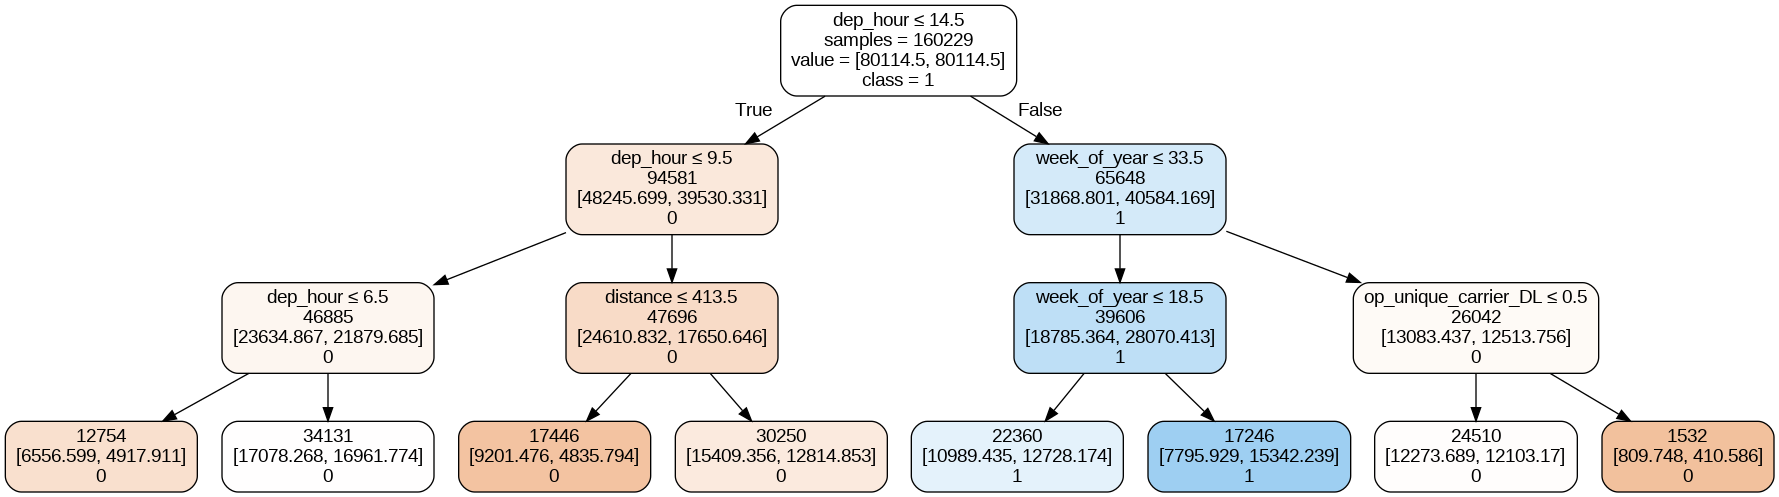

In [ ]:
df_tree_balanced = DecisionTreeClassifier(max_depth=3,class_weight='balanced',random_state=1)

# fit it with the training data
df_tree_balanced.fit(train_x,train_y)

plotDecisionTree(df_tree_balanced, feature_names=x.columns, class_names=df_tree_balanced.classes_)

In [ ]:
classificationSummary(y_true=valid_y, y_pred=df_tree_balanced.predict(valid_x))

Confusion Matrix (Accuracy 0.7158)

       Prediction
Actual     0     1
     0 72509 22496
     1  7863  3952


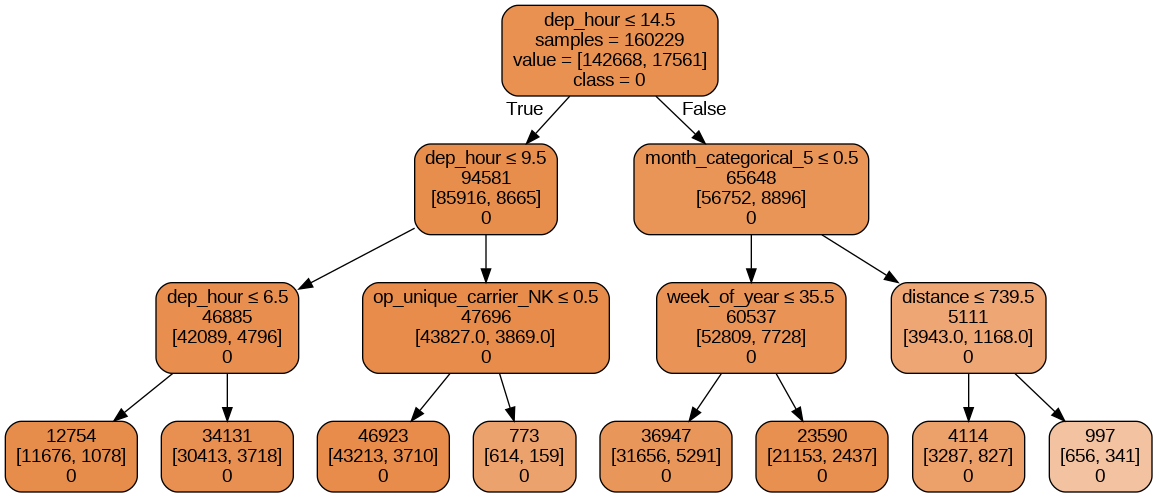

In [ ]:
#Decision Tree
df_tree_unbalanced = DecisionTreeClassifier(max_depth=3,random_state=1)

# fit it with the training data
df_tree_unbalanced.fit(train_x,train_y)

plotDecisionTree(df_tree_unbalanced, feature_names=x.columns, class_names=df_tree_unbalanced.classes_)

In [ ]:
classificationSummary(y_true=valid_y, y_pred=df_tree_unbalanced.predict(valid_x))

Confusion Matrix (Accuracy 0.8894)

       Prediction
Actual     0     1
     0 95005     0
     1 11815     0


## Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_balanced = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=1
)

rf_balanced.fit(train_x, train_y)

RandomForestClassifier(class_weight='balanced', random_state=1)

In [ ]:
classificationSummary(y_true=valid_y, y_pred=rf_balanced.predict(valid_x))

Confusion Matrix (Accuracy 0.8730)

       Prediction
Actual     0     1
     0 92338  2667
     1 10898   917


In [ ]:
rf_unbalanced = RandomForestClassifier(n_estimators=500, random_state=1)
# fit it with training dataset
rf_unbalanced.fit(train_x, train_y)

RandomForestClassifier(n_estimators=500, random_state=1)

In [ ]:
classificationSummary(y_true=valid_y, y_pred=rf_unbalanced.predict(valid_x))

Confusion Matrix (Accuracy 0.8725)

       Prediction
Actual     0     1
     0 92231  2774
     1 10850   965


## Logistic Regression

In [ ]:
log_balanced = LogisticRegression(class_weight='balanced', max_iter=5000, random_state=1)
log_balanced.fit(train_x, train_y)

LogisticRegression(class_weight='balanced', max_iter=5000, random_state=1)

In [ ]:
classificationSummary(y_true=valid_y, y_pred=log_balanced.predict(valid_x))

Confusion Matrix (Accuracy 0.5721)

       Prediction
Actual     0     1
     0 54354 40651
     1  5055  6760


In [ ]:
log_unbalanced = LogisticRegression( max_iter=1000)
log_unbalanced.fit(train_x, train_y)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000)

In [ ]:
classificationSummary(y_true=valid_y, y_pred=log_unbalanced.predict(valid_x))

Confusion Matrix (Accuracy 0.8894)

       Prediction
Actual     0     1
     0 95005     0
     1 11815     0


## XGBoost

In [ ]:
from xgboost import XGBClassifier

xgb_scale = XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    scale_pos_weight= (train_y == 0).sum() / (train_y == 1).sum(),
    random_state=1
)

xgb_scale.fit(train_x, train_y)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=100,
              n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
classificationSummary(y_true=valid_y, y_pred=xgb_scale.predict(valid_x))

Confusion Matrix (Accuracy 0.6337)

       Prediction
Actual     0     1
     0 61003 34002
     1  5121  6694


In [ ]:
xgb_unscale = XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    random_state=1
)

xgb_unscale.fit(train_x, train_y)

pred_xgb_unscale = xgb_unscale.predict(valid_x)

In [ ]:
classificationSummary(y_true=valid_y, y_pred=xgb_unscale.predict(valid_x))

Confusion Matrix (Accuracy 0.8894)

       Prediction
Actual     0     1
     0 94981    24
     1 11792    23


In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(valid_y, pred_xgb_unscale)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['On Time', 'Delayed'])
disp.plot()
plt.show()

#Focus on best Algorithm & Create More visualizations

## Choosing the Best Algorithm

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    recall_score,
    precision_score,
    f1_score
)

import pandas as pd

model_list = [
    ('Decision Tree Balanced', df_tree_balanced),
    ('Decision Tree Unbalanced', df_tree_unbalanced),
    ('Random Forest Balanced', rf_balanced),
    ('Random Forest Unbalanced', rf_unbalanced),
    ('Logistic Regression Balanced', log_balanced),
    ('Logistic Regression Unbalanced', log_unbalanced),
    ('XGBoost Scaled', xgb_scale),
    ('XGBoost Unscaled', xgb_unscale)
]

results = []

for name, model in model_list:

    preds = model.predict(valid_x)

    results.append({
        'Model': name,
        'Accuracy': accuracy_score(valid_y, preds),
        'Balanced_Accuracy': balanced_accuracy_score(valid_y, preds),
        'Recall': recall_score(valid_y, preds),
        'Precision': precision_score(valid_y, preds, zero_division=0),
        'F1_Score': f1_score(valid_y, preds, zero_division=0)
    })

# Create dataframe
summary_df = pd.DataFrame(results)

# Round values
summary_df = summary_df.round(3)

# Sort by strongest F1 score
summary_df = summary_df.sort_values(
    by='F1_Score',
    ascending=False
).reset_index(drop=True)

# Display dataframe
summary_df

,Model,Accuracy,Balanced_Accuracy,Recall,Precision,F1_Score
0,XGBoost Scaled,0.634,0.604,0.567,0.164,0.255
1,Logistic Regression Balanced,0.572,0.572,0.572,0.143,0.228
2,Decision Tree Balanced,0.716,0.549,0.334,0.149,0.207
3,Random Forest Unbalanced,0.872,0.526,0.082,0.258,0.124
4,Random Forest Balanced,0.873,0.525,0.078,0.256,0.119
5,XGBoost Unscaled,0.889,0.501,0.002,0.489,0.004
6,Decision Tree Unbalanced,0.889,0.500,0.000,0.000,0.000
7,Logistic Regression Unbalanced,0.889,0.500,0.000,0.000,0.000


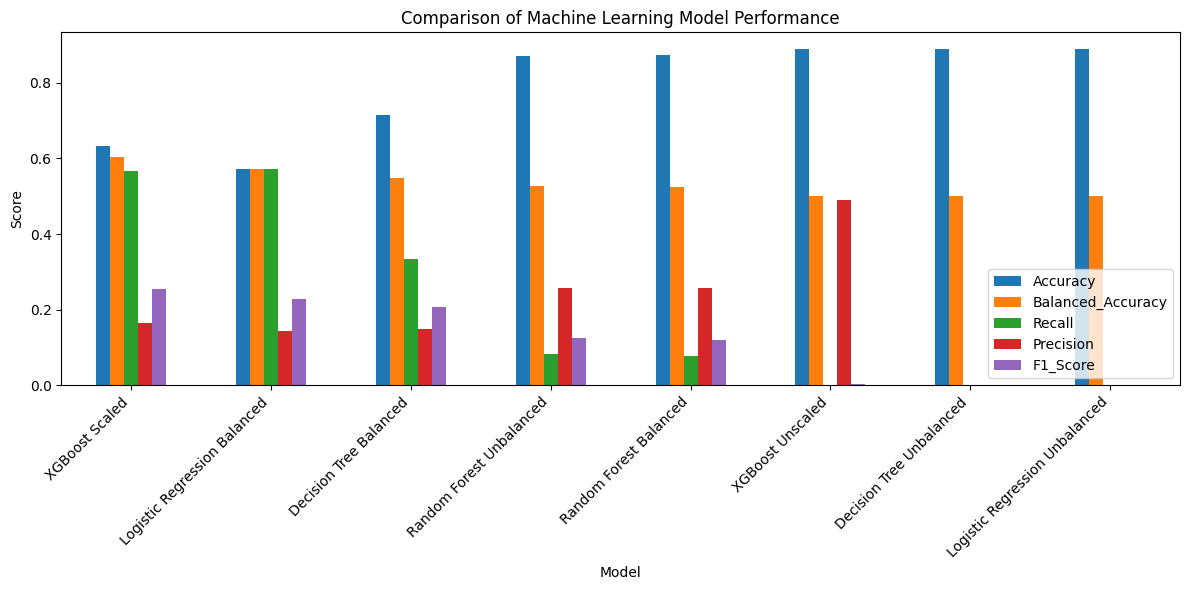

In [ ]:
import matplotlib.pyplot as plt

plot_df = summary_df.set_index('Model')

plot_df[['Accuracy',
         'Balanced_Accuracy',
         'Recall',
         'Precision',
         'F1_Score']].plot(
    kind='bar',
    figsize=(12,6)
)

plt.title('Comparison of Machine Learning Model Performance')
plt.ylabel('Score')
plt.xticks(rotation=45, ha='right')
plt.legend(loc='lower right')
plt.tight_layout()

plt.show()

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    recall_score,
    precision_score,
    f1_score
)

import pandas as pd

top_models = [
    ('XGBoost Scaled', xgb_scale),
    ('Random Forest Balanced', rf_balanced)
]

results = []

for name, model in top_models:

    pred = model.predict(valid_x)

    results.append({
        'Model': name,
        'Accuracy': accuracy_score(valid_y, pred),
        'Balanced Accuracy': balanced_accuracy_score(valid_y, pred),
        'Recall': recall_score(valid_y, pred),
        'Precision': precision_score(valid_y, pred, zero_division=0),
        'F1 Score': f1_score(valid_y, pred, zero_division=0)
    })

top_df = pd.DataFrame(results)

top_df = top_df.round(3)

top_df

,Model,Accuracy,Balanced Accuracy,Recall,Precision,F1 Score
0,XGBoost Scaled,0.634,0.604,0.567,0.164,0.255
1,Random Forest Balanced,0.873,0.525,0.078,0.256,0.119


##### XGBoost Scaled was selected as the final model because it achieved the strongest balance between identifying delayed flights and overall predictive performance.

## Evaluating the Predictors

### Coefficients

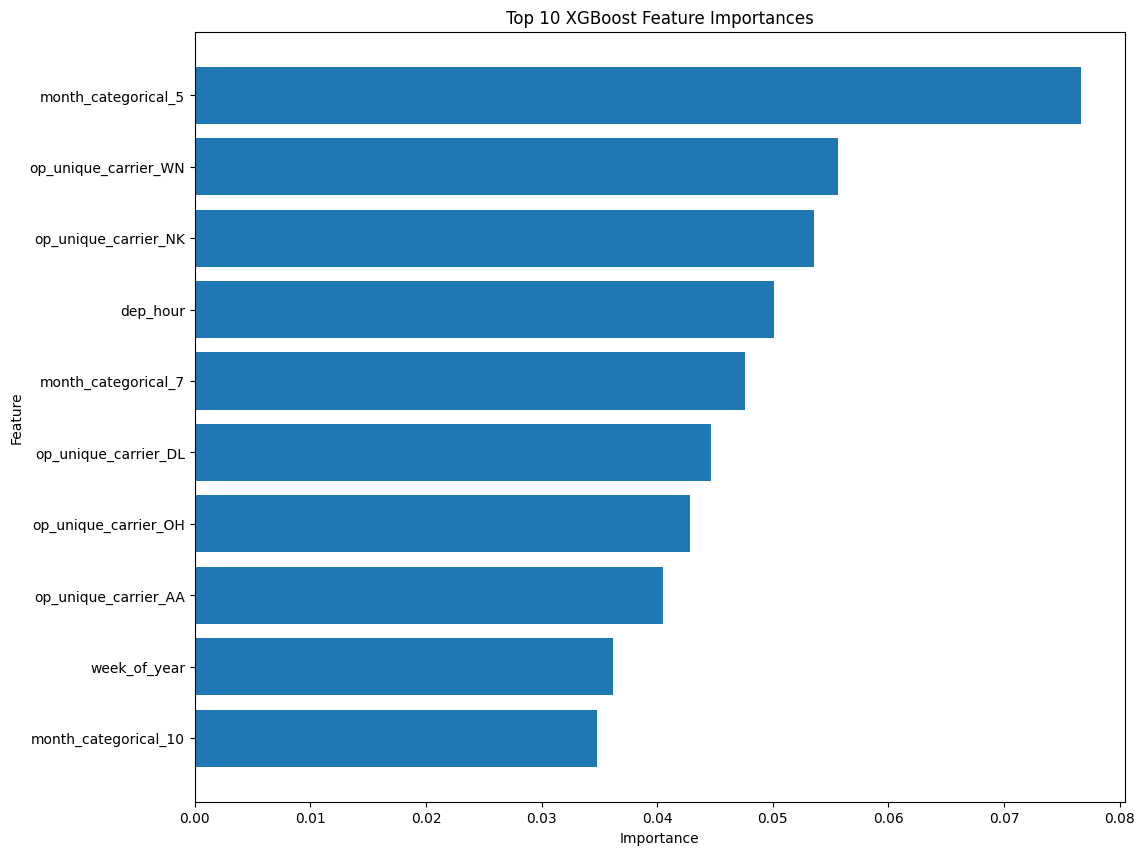

In [ ]:
imp = pd.DataFrame(
    {'feature' : x.columns,
     'importance' : xgb_scale.feature_importances_}
)
imp['abs_importance'] = imp.importance.abs()
imp = imp.sort_values(by='abs_importance', ascending=False).head(10)

plt.figure(figsize=(12, 10))
plt.barh(imp.feature, imp.importance)
plt.title('Top 10 XGBoost Feature Importances')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.gca().invert_yaxis() # Invert y-axis to have the most important feature at the top
plt.show()

### SHAP

In [ ]:
import shap

explainer = shap.Explainer(xgb_scale, train_x.astype(float))

shap_values = explainer(valid_x.sample(100, random_state = 1).astype(float))

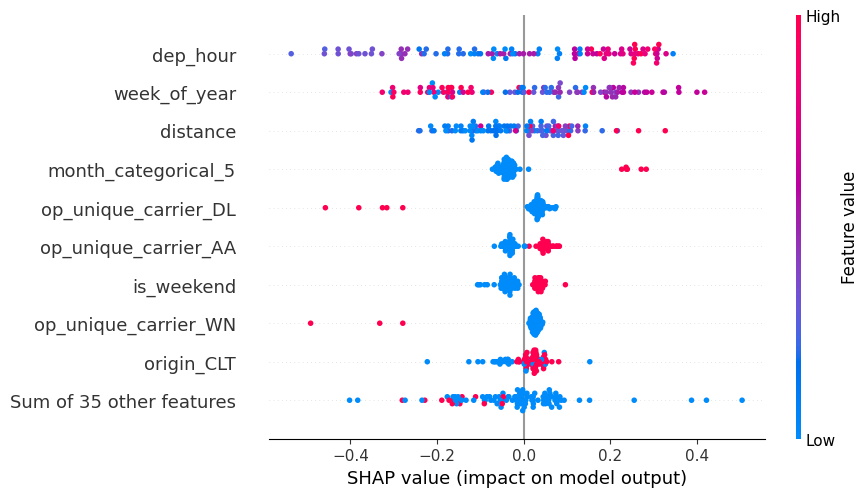

In [ ]:
shap.plots.beeswarm(shap_values, max_display=10)

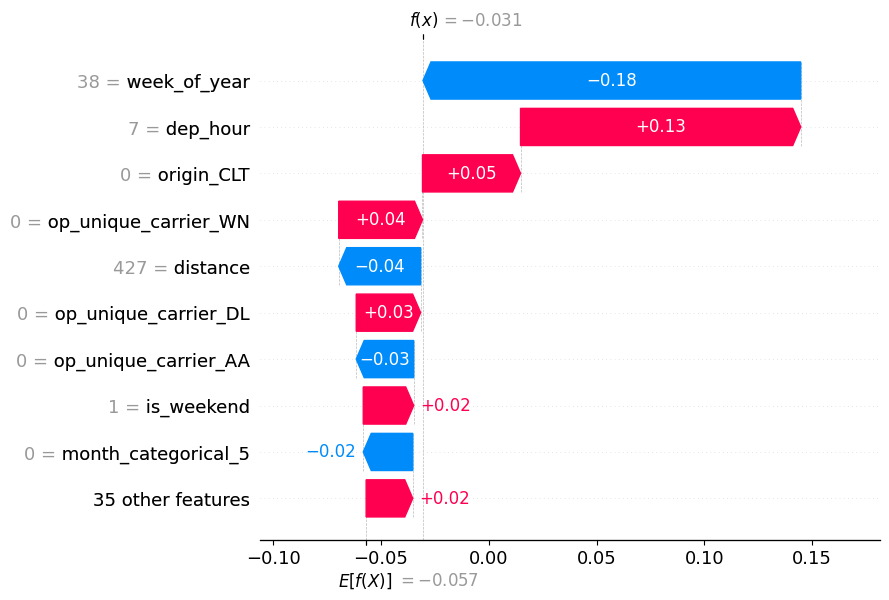

In [ ]:
shap.plots.waterfall(shap_values[5], max_display=10)

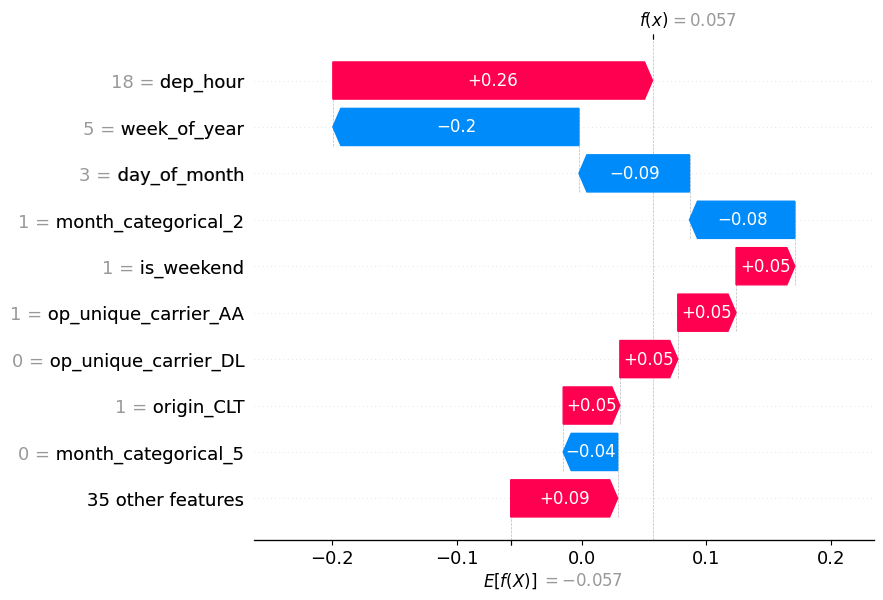

In [ ]:
shap.plots.waterfall(shap_values[20], max_display=10)

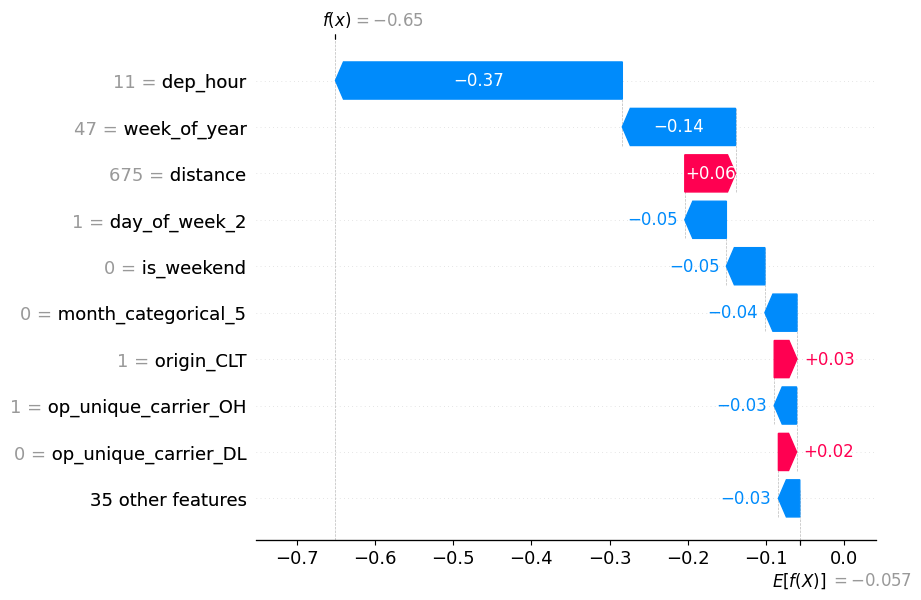

In [ ]:
shap.plots.waterfall(shap_values[50], max_display=10)